# Analyzing the top hosts of Coronaviridae

In [49]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [115]:
def column_stats(df, column_name, n=None): #function to show how often value shows in column
    if n is None:
        n = df.shape[0] #n = rows. df.shape[0] = rows. 
    count_column_name = column_name + "_count" #making labels for columns. (host_count, virus_count...)
    count_df = pd.DataFrame(df[column_name].value_counts()).reset_index() #makes dataframe and counts how many times 
    #value appears in column. Resets index to display as normal table
    
    count_df.columns=[column_name, count_column_name] #using variable above that made the column labels and
    #assining them to the dataframe's columns. the first column holds unique name values, second column
    #represents the count of them
    
    count_df[column_name + "_percent"] = count_df[count_column_name].apply(lambda x: int(x)/n*100)
    #showing percent of columns a specific value takes up
    print(f"Number of unique values = {len(df[column_name].unique())}")
    #prints the amount of unique values
    print(f"{count_df}")
    return count_df #returns the data frame
# def column_stats(df, id_column, name_column, tax_id_column, n=None):
#     if n is None:
#         n = df.shape[0]
#     count_column = name_column + "_count"
#     count_df = df[[name_column, tax_id_column, id_column]].groupby([name_column, tax_id_column]).count().reset_index()
#     count_df.columns=[name_column, tax_id_column, count_column]
#     count_df[name_column + "_percent"] = count_df[count_column].apply(lambda x: int(x)/n*100)
#     print(f"Number of unique values = {len(df[name_column].unique())}")
#     return count_df

#Filters dataframe to show rows only if the value has a column as well
def filter_with_threshold_percentage(df, column_name, threshold, n=None):
    print(f"Size of df = {df.shape}") #size of the data frame. amount of rows and columns before we filter
    if n is None:
        n = df.shape[0] #makes n the number of rows
    print(f"n= {n}") #prints amount of rows
    count_df = column_stats(df, column_name, n=n) #calling in previous function, passing in data frame, the column name, and #rows
    #Gets amt of times (count) value appears in the data frame column
    
    percent_column_name = column_name + "_percent" #making variable
    
    filtered_count_df = count_df[count_df[percent_column_name] >= threshold]
    #keep the values that are greater than threshold percent. get count of them
    
    filtered_df = df[df[column_name].isin(list(filtered_count_df[column_name].values))]
    #checks list of filtered columns. only keeps rows where the value in the row's column has been filtered
    #converts array of allowed filtered values into a list and checks every row (df[column_name].isin...) 
    #to see if its value is in the list
    #calling df[] on the entire thing represents it in boolean values. true if row is eligible, false if not.
    #keeps only true rows. 
    
    print(f"Size of filtered df = {filtered_df.shape}") #how many columns are in the dataframeafter filtered
    column_stats(filtered_df, column_name, n=n) #calls column_stats method from before
    #gets amount of times (count) value appears in the filtered dataframe columns
    return filtered_df #returns filtered dataframe

In [116]:
#Filters dataframe to include rows where value appears at least 'threshold' amount of times
def filter_with_threshold_count(df, column_name, threshold, n=None):
    print(f"Size of df = {df.shape}") #prints original size of dataframe before modifying
    n = df.shape[0] # n is equal to the amount of columns
    count_df = column_stats(df, column_name, n=n) #count & percentage for each unique value
    count_column_name = column_name + "_count" #name of count column
    filtered_count_df = count_df[count_df[count_column_name] >= threshold] #keeys rows with values that show
    #at least threshold times
    filtered_df = df[df[column_name].isin(list(filtered_count_df[column_name].values))]
    #creates filtered dataframe that contains rows which only have filtered column values
    print(f"Size of filtered df = {filtered_df.shape}") #prints filtered dataframe size
    column_stats(filtered_df, column_name, n=n) #stats for the filtered dataframe
    return filtered_df

def print_seq_len_histogram(df, n_bins):
    sns.histplot(df["seq_len"]) #creats histogram plot of sequence lengths
    #displays the min and max lengths
    print(f"min seq len = {min(df['seq_len'])}")
    print(f"max seq len = {max(df['seq_len'])}")
    plt.show()
    
    freq, bins = np.histogram(df["seq_len"], bins=n_bins)
    #frequency of bins displayed using numpy.
    #the diff sequences are split into even bins 
    n = df.shape[0] #represents rows
    hist_map = [] #creating list to store the histogram data
    for i in range(n_bins): #going thru bins
        hist_map.append({"start": bins[i], "end":bins[i+1], "count": freq[i], "percentage": freq[i]/n*100})
        #creating the table, starting and ending values for each bin, also shows count and percentage of the value
        #the bins hold sequence lengths
    hist_df = pd.DataFrame(hist_map) #dataframe of histogram created
    print(hist_df) #histogram dataframe printed.

In [174]:
#file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/uniref_taxonomy_id_11118_AND_identit_2025_06_13_uniprot_metadata_embl_hosts_pruned_metadata.csv")
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/uniref_taxonomy_id_11118_AND_identit_2025_06_13_uniprot_metadata_embl_hosts_pruned_metadata_species_virus_species_virus_host_vertebrates_w_seq.csv")
df = pd.read_csv(file_path)
df
output = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/coronaviridae/uniref50_validhosts.csv")
df.to_csv(output, index=False)
	
# df_bat = df[df["virus_host_name"] == "bat"]
# df_bat #why does this only have 21 occurrences?
# sum(df["virus_host_name"] != "None")

<b> Filtering the dataframe so its valid </b>

valid_tax : the data frame after removing the "no rank" rows from the virus taxon rank/

In [179]:
df = df[df["virus_host_tax_id"] == 9606]
df
#9606

,uniref50_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,seq
0,UniRef50_A0A0H3VE52,277944,[9606],AKA09614.1,['Homo sapiens'],homo sapiens,Human coronavirus NL63,species,9606,species,VLPLASCFFTCNSNANLSMLQLGVPDNSSTIVTGLLPTHWICANQS...
15,UniRef50_A0A0P0HQR0,290028,[9606],ALJ77702.1,['Homo sapiens'],homo sapiens,Human coronavirus HKU1,species,9606,species,PPHNGVLEITACQYTMCEYPHTICKSKGSFRNESWHFDKSEPLCLF...
17,UniRef50_A0A0X8HHR0,1335626,NaN,AMD02834.1,['Homo sapiens'],homo sapiens,Middle East respiratory syndrome-related coron...,species,9606,species,TFIDAARGPAGVESDVETNEIVDSVQYAHKHDIQITNESYNNYVPS...
18,UniRef50_A0A127ATN8,11137,[9606],AMM42532.1,['Homo sapiens'],homo sapiens,Human coronavirus 229E,species,9606,species,SVSGSQFTTGFVYFNGTGRGACKGFYSNASSDVIRYNINFEENLRR...
19,UniRef50_A8W385,277944,[9606],ABW71808.1,['Homo sapiens'],homo sapiens,Human coronavirus NL63,species,9606,species,DGARLFSSDLSTLAVTAIVVVGGCVTSNVPPIVSEKISVMDKLDTG...
20,UniRef50_A0A127AU88,290028,[9606],AMM42367.1,['Homo sapiens'],homo sapiens,Human coronavirus HKU1,species,9606,species,ANELSRLVKSPTVREYIRYGIKPFTIPIDLLCLRDDNQTLLVPKIF...
37,UniRef50_Q5MQC9,290028,[9606],AAT98582.1,['Homo sapiens'],homo sapiens,Human coronavirus HKU1,species,9606,species,MDVWRPSYTHSLVIREFGVTNLEDLCLKYNYCQPIVGYCIVPLNVW...
38,UniRef50_A0A191KB23,1335626,NaN,AMQ49019.1,['Homo sapiens'],homo sapiens,Middle East respiratory syndrome-related coron...,species,9606,species,MAFSASLFKPVQLVPVSPAFHRIESTDSIVFTYIPASGYVAALAVN...
41,UniRef50_C1J1F3,11137,[9606],ACO44682.1,['Homo sapiens'],homo sapiens,Human coronavirus 229E,species,9606,species,VFAVESGGYIPSNFAFNNWFLLTNTSSVVDGVVRSFQPLLLNCLWS...
57,UniRef50_D3GDY4,290028,[9606],ACV87146.1,['Homo sapiens'],homo sapiens,Human coronavirus HKU1,species,9606,species,IGDFNCTNFAINDLNTTIPRISEYVVDVSYGLGTYYILDRVYLNTT...


In [175]:
#column_stats(df[df["virus_taxon_rank"] == "species"], "virus_host_name")
#only 91 values where the virus name is valid

#Data frame after taking out the invald virus taxon ranks

valid_tax = column_stats(df, "virus_host_tax_id")
valid_tax
n
#106 valid tax id 

Number of unique values = 78
    virus_host_tax_id  virus_host_tax_id_count  virus_host_tax_id_percent
0                9606                       45                  19.230769
1                9031                       18                   7.692308
2                9986                       10                   4.273504
3                9838                        8                   3.418803
4                9823                        7                   2.991453
..                ...                      ...                        ...
73            1868627                        1                   0.427350
74             247625                        1                   0.427350
75             229078                        1                   0.427350
76              94961                        1                   0.427350
77               9925                        1                   0.427350

[78 rows x 3 columns]


,virus_host_tax_id,virus_host_tax_id_count,virus_host_tax_id_percent
0,9606,45,19.230769
1,9031,18,7.692308
2,9986,10,4.273504
3,9838,8,3.418803
4,9823,7,2.991453
...,...,...,...
73,1868627,1,0.427350
74,247625,1,0.427350
75,229078,1,0.427350
76,94961,1,0.427350


In [178]:
#df = column_stats(df, "virus_name")
host_df = column_stats(df, "virus_host_name")
#host_df = host_df[["virus_host_name", "virus_host_tax_id"]]
host_df
#107 hosts are valid

Number of unique values = 82
           virus_host_name  virus_host_name_count  virus_host_name_percent
0             homo sapiens                     45                19.230769
1                  chicken                     12                 5.128205
2    oryctolagus cuniculus                     10                 4.273504
3                    camel                      8                 3.418803
4        branta canadensis                      7                 2.991453
..                     ...                    ...                      ...
77            ochotona sp.                      1                 0.427350
78        scarus psittacus                      1                 0.427350
79  chromis atripectoralis                      1                 0.427350
80   mystacina tuberculata                      1                 0.427350
81                    goat                      1                 0.427350

[82 rows x 3 columns]


,virus_host_name,virus_host_name_count,virus_host_name_percent
0,homo sapiens,45,19.230769
1,chicken,12,5.128205
2,oryctolagus cuniculus,10,4.273504
3,camel,8,3.418803
4,branta canadensis,7,2.991453
...,...,...,...
77,ochotona sp.,1,0.427350
78,scarus psittacus,1,0.427350
79,chromis atripectoralis,1,0.427350
80,mystacina tuberculata,1,0.427350


# Sequence Length Analysis

In [20]:
seq_file = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/uniref_taxonomy_id_11118_AND_identit_2025_06_13_uniprot_metadata_embl_hosts_pruned_metadata_species_virus_species_virus_host_vertebrates_w_seq.csv")
seq_df = pd.read_csv(seq_file)
seq_df
#Making a sequence length column that gets length of sequences
seq_df["seq_len"] = seq_df["seq"].apply(lambda x: len(x))
seq_df = seq_df[~seq_df.duplicated()]
print(seq_df.head())
print(seq_df.shape)

column_stats(seq_df, "virus_name").to_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/uniref_taxonomy_id_10239_AND_identit_2025_06_13_uniprot_metadata_embl_hosts_pruned_metadata_species_virus.csv"))

           uniref50_id   tax_id uniprot_host_tax_ids embl_ref_id  \
0  UniRef50_A0A0H3VE52   277944               [9606]  AKA09614.1   
1  UniRef50_A0A5P9K482    28295                  NaN  QFU19298.1   
2  UniRef50_A0A5Q0TWF5  2664184                  NaN  QGA70694.1   
3  UniRef50_A0A0K0Q056   694014                  NaN  AKR04371.1   
4  UniRef50_A0A5Q2UT18   694014                  NaN  QGH51290.1   

            embl_host_name      virus_host_name  \
0         ['Homo sapiens']         homo sapiens   
1                ['swine']                swine   
2  ['Erinaceus amurensis']  erinaceus amurensis   
3              ['chicken']              chicken   
4        ['Gallus gallus']        gallus gallus   

                             virus_name virus_taxon_rank  virus_host_tax_id  \
0                Human coronavirus NL63          species               9606   
1       Porcine epidemic diarrhea virus          species               9823   
2  Erinaceus hedgehog coronavirus HKU31        

In [21]:
#Five common hosts
column_stats(df, "virus_host_name").to_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/uniref_taxonomy_id_10239_AND_identit_2025_06_13_uniprot_metadata_embl_hosts_pruned_metadata_species_virus_species_virus_host.csv"))
#173 unique hosts
#common = humans, gallus gallus, chicken, felis catus, bat
print(column_stats(df, "virus_host_name"))

Number of unique values = 173
            virus_host_name  virus_host_name_count  virus_host_name_percent
0              homo sapiens                    125                18.545994
1             gallus gallus                     32                 4.747774
2                   chicken                     29                 4.302671
3               felis catus                     26                 3.857567
4                       bat                     21                 3.115727
..                      ...                    ...                      ...
168  chromis atripectoralis                      1                 0.148368
169        scarus psittacus                      1                 0.148368
170   mystacina tuberculata                      1                 0.148368
171                    goat                      1                 0.148368
172                  donkey                      1                 0.148368

[173 rows x 3 columns]
Number of unique values = 173
    

min seq len = 27
max seq len = 7078


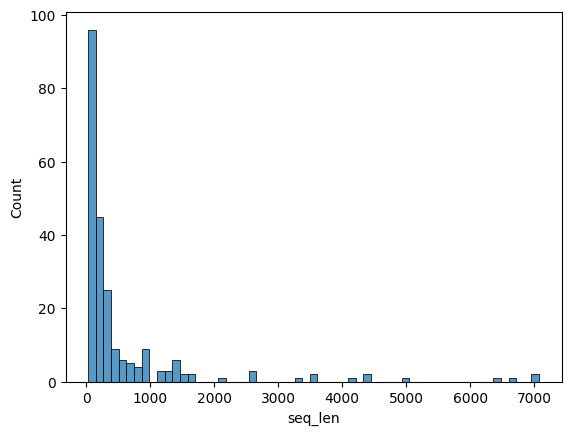

          start          end  count  percentage
0     27.000000   614.583333    180   78.260870
1    614.583333  1202.166667     21    9.130435
2   1202.166667  1789.750000     14    6.086957
3   1789.750000  2377.333333      1    0.434783
4   2377.333333  2964.916667      3    1.304348
5   2964.916667  3552.500000      3    1.304348
6   3552.500000  4140.083333      1    0.434783
7   4140.083333  4727.666667      2    0.869565
8   4727.666667  5315.250000      1    0.434783
9   5315.250000  5902.833333      0    0.000000
10  5902.833333  6490.416667      1    0.434783
11  6490.416667  7078.000000      3    1.304348


In [22]:
print_seq_len_histogram(seq_df, 12)

In [23]:
virus_names = list(df["virus_name"].unique())
print(f"Number of unique viruses = {len(virus_names)}")
virus_names

idv = list(filter(lambda x: "immunodeficiency" in x.lower(), virus_names))
idv_df = df[df["virus_name"].isin(idv)]
idv_df.shape #prints zero, not a single immunodeficient


non_idv_df = df[~df["virus_name"].isin(idv)] #filtering OUT virus_name. 
non_idv_df.shape

Number of unique viruses = 145


(674, 10)

In [24]:
output_file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/uniref50_coronaviridae_embl_hosts_pruned_metadata_species_vertebrates_w_seq_non_idv.csv")
non_idv_df.to_csv(output_file_path, index=False)
column_stats(non_idv_df, "virus_name").to_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/uniref50_coronaviridae_embl_hosts_pruned_species_vertebrates_nonidv_virus.csv"))

Number of unique values = 145
                                            virus_name  virus_name_count  \
0                                        Coronaviridae                90   
1                          Infectious bronchitis virus                49   
2      Severe acute respiratory syndrome coronavirus 2                47   
3    Middle East respiratory syndrome-related coron...                43   
4                                   Feline coronavirus                34   
..                                                 ...               ...   
140                       Scarus psittacus coronavirus                 1   
141                      Bat coronavirus Mr/Shanxi2011                 1   
142                 Chromis atripectoralis coronavirus                 1   
143             Mystacina coronavirus New Zealand/2013                 1   
144                      unclassified Gammacoronavirus                 1   

     virus_name_percent  
0             13.353116  
1    

In [25]:
column_stats(non_idv_df, "virus_host_name").to_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/uniref50_coronaviridae_embl_hosts_pruned_species_vertebrates_nonidv_virus_host.csv"))
#173 unique virus hosts, 145 unique viruses that are non idv

Number of unique values = 173
            virus_host_name  virus_host_name_count  virus_host_name_percent
0              homo sapiens                    125                18.545994
1             gallus gallus                     32                 4.747774
2                   chicken                     29                 4.302671
3               felis catus                     26                 3.857567
4                       bat                     21                 3.115727
..                      ...                    ...                      ...
168  chromis atripectoralis                      1                 0.148368
169        scarus psittacus                      1                 0.148368
170   mystacina tuberculata                      1                 0.148368
171                    goat                      1                 0.148368
172                  donkey                      1                 0.148368

[173 rows x 3 columns]


In [26]:
filtered_df = filter_with_threshold_percentage(non_idv_df, "virus_host_name", 2)
#Could filter by 2% prevalence so we get top 6 hosts, 3% or just above 2.53 for 5 hosts

Size of df = (674, 10)
n= 674
Number of unique values = 173
            virus_host_name  virus_host_name_count  virus_host_name_percent
0              homo sapiens                    125                18.545994
1             gallus gallus                     32                 4.747774
2                   chicken                     29                 4.302671
3               felis catus                     26                 3.857567
4                       bat                     21                 3.115727
..                      ...                    ...                      ...
168  chromis atripectoralis                      1                 0.148368
169        scarus psittacus                      1                 0.148368
170   mystacina tuberculata                      1                 0.148368
171                    goat                      1                 0.148368
172                  donkey                      1                 0.148368

[173 rows x 3 columns]
Size

In [27]:
filter_three = filter_with_threshold_percentage(non_idv_df, "virus_host_name", 3)

output_file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/uniref50_coronaviridae_embl_threepercent.csv")
filter_three.to_csv(output_file_path, index=False) #only keep for first time. 
filter_three

Size of df = (674, 10)
n= 674
Number of unique values = 173
            virus_host_name  virus_host_name_count  virus_host_name_percent
0              homo sapiens                    125                18.545994
1             gallus gallus                     32                 4.747774
2                   chicken                     29                 4.302671
3               felis catus                     26                 3.857567
4                       bat                     21                 3.115727
..                      ...                    ...                      ...
168  chromis atripectoralis                      1                 0.148368
169        scarus psittacus                      1                 0.148368
170   mystacina tuberculata                      1                 0.148368
171                    goat                      1                 0.148368
172                  donkey                      1                 0.148368

[173 rows x 3 columns]
Size

,uniref50_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank
1,UniRef50_A0A0H3VE52,277944,[9606],AKA09614.1,['Homo sapiens'],homo sapiens,Human coronavirus NL63,species,9606,species
3,UniRef50_A0A0H3VFW7,31631,[9606],AKA09662.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species
5,UniRef50_A3EX95,11118,[258959],ABN10840.1,['bat'],bat,Coronaviridae,family,0,NaN
7,UniRef50_A3EX97,11118,[258959],ABN10842.1,['bat'],bat,Coronaviridae,family,0,NaN
10,UniRef50_A3EX98,11118,[258959],ABN10843.1,['bat'],bat,Coronaviridae,family,0,NaN
...,...,...,...,...,...,...,...,...,...,...
650,UniRef50_W6A976,1335626,NaN,AHI48785.1,['Homo sapiens'],homo sapiens,Middle East respiratory syndrome-related coron...,species,9606,species
654,UniRef50_N1NTJ5,12663,NaN,CCW59376.1,['Felis catus'],felis catus,Feline coronavirus,no rank,9685,species
658,UniRef50_X5CNV6,694014,NaN,AHW48920.1,['chicken'],chicken,Avian coronavirus,species,9031,species
661,UniRef50_X5D4P7,11120,NaN,AHW49209.1,['chicken'],chicken,Infectious bronchitis virus,no rank,9031,species


In [28]:
#5 common virus hosts
column_stats(filter_three, "virus_host_name")

Number of unique values = 5
  virus_host_name  virus_host_name_count  virus_host_name_percent
0    homo sapiens                    125                53.648069
1   gallus gallus                     32                13.733906
2         chicken                     29                12.446352
3     felis catus                     26                11.158798
4             bat                     21                 9.012876


,virus_host_name,virus_host_name_count,virus_host_name_percent
0,homo sapiens,125,53.648069
1,gallus gallus,32,13.733906
2,chicken,29,12.446352
3,felis catus,26,11.158798
4,bat,21,9.012876


In [29]:
#18 common viruses
column_stats(filter_three, "virus_name")

Number of unique values = 19
                                           virus_name  virus_name_count  \
0     Severe acute respiratory syndrome coronavirus 2                47   
1                         Infectious bronchitis virus                43   
2                                       Coronaviridae                32   
3   Middle East respiratory syndrome-related coron...                28   
4                                  Feline coronavirus                22   
5                                   Avian coronavirus                18   
6                              Human coronavirus OC43                 6   
7                              Human coronavirus 229E                 6   
8                              Human coronavirus HKU1                 6   
9                              Human coronavirus NL63                 5   
10                                 Orthocoronavirinae                 4   
11                                    Betacoronavirus                 3

,virus_name,virus_name_count,virus_name_percent
0,Severe acute respiratory syndrome coronavirus 2,47,20.171674
1,Infectious bronchitis virus,43,18.454936
2,Coronaviridae,32,13.733906
3,Middle East respiratory syndrome-related coron...,28,12.017167
4,Feline coronavirus,22,9.442060
5,Avian coronavirus,18,7.725322
6,Human coronavirus OC43,6,2.575107
7,Human coronavirus 229E,6,2.575107
8,Human coronavirus HKU1,6,2.575107
9,Human coronavirus NL63,5,2.145923


In [30]:
three_prev = filter_three["virus_host_name"].unique().tolist()
three_prev

['homo sapiens', 'bat', 'gallus gallus', 'chicken', 'felis catus']

# Host Taxon ID Distribution

<b> Instead of looking at prevalence, we will look at the number of samples per host to ensure there's an adequate amount of samples available for training </b>

In [185]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/data/uniref_taxonomy_id_11118_AND_identit_2025_06_13_uniprot_metadata_embl_hosts_pruned_metadata.csv")
df = pd.read_csv(file_path)
df
# df = df[["virus_host_tax_id", "virus_host_name"]]
# df
# column_stats(df, "virus_host_tax_id")

output = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/coronaviridae/uniref50_validhosts.csv")
df.to_csv(output, index=False)

#Data frame after taking out the invald virus taxon ranks

# valid_tax = column_stats(df, "virus_host_tax_id")
# valid_tax
df

,uniref50_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank
0,UniRef50_A0A5J6YH13,1586324,NaN,QFP39650.1,['pig'],pig,Porcine deltacoronavirus,no rank,9823,species
1,UniRef50_A0A0H3VE52,277944,[9606],AKA09614.1,['Homo sapiens'],homo sapiens,Human coronavirus NL63,species,9606,species
2,UniRef50_A0A5P9K482,28295,NaN,QFU19298.1,['swine'],swine,Porcine epidemic diarrhea virus,species,9823,species
3,UniRef50_A0A0H3VFW7,31631,[9606],AKA09662.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species
4,UniRef50_A0A5Q0TVS7,11118,NaN,QGA70693.1,['Erinaceus amurensis'],erinaceus amurensis,Coronaviridae,family,757341,species
...,...,...,...,...,...,...,...,...,...,...
669,UniRef50_A0A4D6FTP0,2569586,NaN,QCB65094.1,['Branta canadensis'],branta canadensis,Canada goose coronavirus,species,8853,species
670,UniRef50_A0A4D6FTX3,2569586,NaN,QCB65098.1,['Branta canadensis'],branta canadensis,Canada goose coronavirus,species,8853,species
671,UniRef50_A0A4D6FWC5,694013,NaN,QCB65106.1,['Branta canadensis'],branta canadensis,Gammacoronavirus,genus,8853,species
672,UniRef50_A0A4P2VDR0,136187,NaN,BBD43534.1,['Donkey'],donkey,Equine coronavirus,no rank,9793,species


In [186]:
print(column_stats(df, "virus_host_tax_id"))

#top_ids = df[df["virus_host_tax_id_count"] >= 19]

Number of unique values = 119
     virus_host_tax_id  virus_host_tax_id_count  virus_host_tax_id_percent
0                    0                      128                  18.991098
1                 9606                      125                  18.545994
2                 9031                       61                   9.050445
3                 9685                       36                   5.341246
4                 9823                       19                   2.818991
..                 ...                      ...                        ...
114             225400                        1                   0.148368
115             229078                        1                   0.148368
116              94961                        1                   0.148368
117               9925                        1                   0.148368
118               9793                        1                   0.148368

[119 rows x 3 columns]
     virus_host_tax_id  virus_host_tax_id_coun

In [187]:
host_tax_count = df["virus_host_tax_id"].value_counts().reset_index()
print(host_tax_count)
#Getting only the virus host tax id and the count

     virus_host_tax_id  count
0                    0    128
1                 9606    125
2                 9031     61
3                 9685     36
4                 9823     19
..                 ...    ...
114             225400      1
115             229078      1
116              94961      1
117               9925      1
118               9793      1

[119 rows x 2 columns]


In [205]:
bat = df[df["virus_host_tax_id".count] >= 10]
bat #there are 100 occurrences of the bat

TypeError: must be str, not DataFrame

In [189]:
humans = df[df["virus_host_tax_id"] == 9606]
humans #homo sapiens. 68 occurrences

,uniref50_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank
1,UniRef50_A0A0H3VE52,277944,[9606],AKA09614.1,['Homo sapiens'],homo sapiens,Human coronavirus NL63,species,9606,species
3,UniRef50_A0A0H3VFW7,31631,[9606],AKA09662.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species
18,UniRef50_A0A663DJA2,11118,[9606],QHI42199.1,['Homo sapiens'],homo sapiens,Coronaviridae,family,9606,species
47,UniRef50_A0A0P0HQR0,290028,[9606],ALJ77702.1,['Homo sapiens'],homo sapiens,Human coronavirus HKU1,species,9606,species
62,UniRef50_A0A6M4EMZ2,2697049,[9606],QTZ30666.1,['Homo sapiens'],homo sapiens,Severe acute respiratory syndrome coronavirus 2,no rank,9606,species
...,...,...,...,...,...,...,...,...,...,...
640,UniRef50_W6A0R5,1335626,NaN,AHI48796.1,['Homo sapiens'],homo sapiens,Middle East respiratory syndrome-related coron...,species,9606,species
644,UniRef50_W6A915,1335626,NaN,AHI48725.1,['Homo sapiens'],homo sapiens,Middle East respiratory syndrome-related coron...,species,9606,species
646,UniRef50_W6A935,1335626,NaN,AHI48745.1,['Homo sapiens'],homo sapiens,Middle East respiratory syndrome-related coron...,species,9606,species
648,UniRef50_W6A938,1335626,NaN,AHI48750.1,['Homo sapiens'],homo sapiens,Middle East respiratory syndrome-related coron...,species,9606,species


In [190]:
chicken = df[df["virus_host_tax_id"] == 9031]
chicken.shape #18 occurrences of gallus gallus/chicken

(61, 10)

<b> It takes gallus gallus and chicken at the same time </b>

In [191]:
felis_catus = df[df["virus_host_tax_id"] == 9685]
print(felis_catus)
felis_catus.shape
#36 occurrences of where the cat is host

             uniref50_id   tax_id uniprot_host_tax_ids embl_ref_id  \
86   UniRef50_A0A125R5C4    12663                  NaN  AMD11161.1   
94   UniRef50_A0A7G7FD37    12663                  NaN  QNF22254.1   
95   UniRef50_A0A7G7FDD2    12663                  NaN  QNF21984.1   
96   UniRef50_A0A7G7FDR9    12663                  NaN  QNF22486.1   
97   UniRef50_A0A7G7FDV4    12663                  NaN  QNF22521.1   
98   UniRef50_A0A7G7FDZ1    12663                  NaN  QNF22558.1   
100  UniRef50_A0A7G7FDZ8    12663                  NaN  QNF22565.1   
101  UniRef50_A0A7G7FE18    12663                  NaN  QNF22499.1   
103  UniRef50_A0A7G7FE25    12663                  NaN  QNF22592.1   
105  UniRef50_A0A7G7FE27    12663                  NaN  QNF22594.1   
107  UniRef50_A0A7G7FE29    12663                  NaN  QNF22596.1   
108  UniRef50_A0A7G7FEG1    12663                  NaN  QNF22729.1   
115      UniRef50_Q52PA5   693996               [9681]  AAY32597.1   
154  UniRef50_A0A7T8

(36, 10)

In [192]:
9685, 9823
pig = df[df["virus_host_tax_id"] == 9823]
print(pig.shape)
pig
#19 occurrences of where the pig is host

(19, 10)


,uniref50_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank
0,UniRef50_A0A5J6YH13,1586324,NaN,QFP39650.1,['pig'],pig,Porcine deltacoronavirus,no rank,9823,species
2,UniRef50_A0A5P9K482,28295,NaN,QFU19298.1,['swine'],swine,Porcine epidemic diarrhea virus,species,9823,species
9,UniRef50_A0A0K0PVT0,2509474,NaN,AKQ63081.1,['pig'],pig,Buldecovirus,subgenus,9823,species
30,UniRef50_A0A0K1RLP8,11146,NaN,AKV62756.1,['pig'],pig,Porcine respiratory coronavirus,no rank,9823,species
37,UniRef50_A0A6G6XDF4,28295,NaN,QIG55585.1,['Sus scrofa'],sus scrofa,Porcine epidemic diarrhea virus,species,9823,species
44,UniRef50_A0A0N7EI25,28295,NaN,ALF12317.1,['swine'],swine,Porcine epidemic diarrhea virus,species,9823,species
51,UniRef50_A0A6H0M5M1,1586324,NaN,QIV13125.1,['pig'],pig,Porcine deltacoronavirus,no rank,9823,species
196,UniRef50_A0A1D8ELP7,1766554,NaN,AOT21920.1,['pig'],pig,Swine enteric coronavirus,no rank,9823,species
216,UniRef50_A0A8A2F689,11149,NaN,QSV11117.1,['pig'],pig,Transmissible gastroenteritis virus,no rank,9823,species
227,UniRef50_D2YZT2,11149,NaN,BAI67828.1,['Sus scrofa'],sus scrofa,Transmissible gastroenteritis virus,no rank,9823,species


In [193]:
#Make a pie chart showing distributions of the taxon id

<b> Top 5 hosts according to the host taxon ids are </b>

- bat
- humans
- gallus / chicken?
- cat
- pig

# Data Viusalization of Host IDs

In [194]:
host_tax_ids = [0, 9606, 9031, 9685, 9823]
host_tax = {
    0: "Bat",
    9606: "Homo Sapiens",
    9031: "Gallus Gallus",
    9685: "Felis Catus",
    9823: "Sus Scrofa"
}


In [195]:
top_ids = host_tax_count[host_tax_count["count"] >= 19]
top_ids.loc[:, "host_name"] = top_ids["virus_host_tax_id"].map(host_tax)
top_ids
output_pdf = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/coronaviridae/top5_id_hostsdf.pdf")
top_ids.to_csv(output_pdf)

/localscratch/ipykernel_2945910/4180924259.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_ids.loc[:, "host_name"] = top_ids["virus_host_tax_id"].map(host_tax)


In [196]:
# top_ids.loc[:, "host_name"] = top_ids["virus_host_tax_id"].map(host_tax)
# top_ids

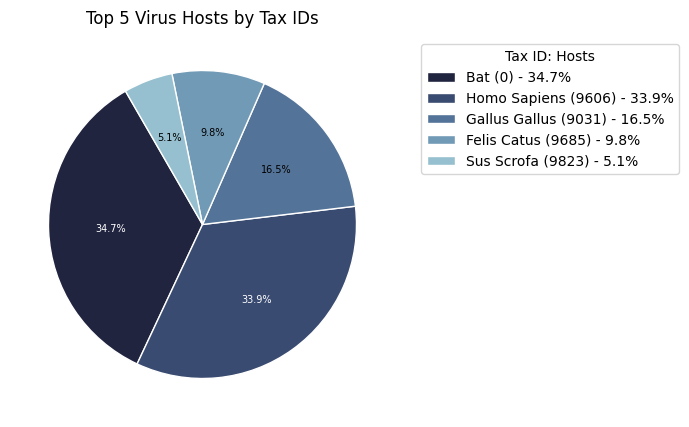

In [197]:
#plt.figure(figsize = (9,5))
total = top_ids["count"].sum()
legend_labels = [f"{row['host_name']} ({row['virus_host_tax_id']}) - {row['count']/total:.1%}" for _, row in top_ids.iterrows()]
fig, ax = plt.subplots(figsize = (9,5))
wedges, texts, autotexts = ax.pie(
    top_ids["count"],
    labels = None,
    autopct = '%1.1f%%',
    startangle = 120,
    colors = sns.cubehelix_palette(rot=-0.2, reverse = True),
    wedgeprops = {"edgecolor": "white"},
    textprops = {"fontsize": 7}
)
for i, autotext in enumerate(autotexts):
    facecolor = wedges[i].get_facecolor()[:3]  # RGB
    brightness = sum(facecolor)  # crude brightness check
    if brightness < 1.2:  # dark background
        autotext.set_color("white")
plt.title("Top 5 Virus Hosts by Tax IDs")
#look at top ten hosts and see what the minimum count is 
#include those above 10 for pre training . 6 is not enough!

ax.legend(wedges, legend_labels, title="Tax ID: Hosts", bbox_to_anchor=(1.05, 0.8), loc="center left")
output_pdf = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/coronaviridae/top5_id_hosts.pdf")
plt.savefig(output_pdf, dpi = 900)
plt.show()



#in config file, look at HOST TAXON ID COLUMN INSTEAD OF VIRUS HOST NAME
#CHANGE SOME LABELS BASED ON THIS

<b> Top 5 Hosts by Taxon IDS </b>
- Bats
- Humans
- Chickens
- Cats
- Pigs
Minimum count being 19

In [198]:
df = df[["virus_host_tax_id", "virus_host_name"]]
top_ids = host_tax_count[host_tax_count["count"] >= 10]
print(top_ids)
#when we print the top hosts with at least 10 occurrences, we have 8 hosts

   virus_host_tax_id  count
0                  0    128
1               9606    125
2               9031     61
3               9685     36
4               9823     19
5               9612     17
6               9838     11
7               9986     10


In [199]:
wolf = df[df["virus_host_tax_id"] == 9612]
wolf #Wolf, 17 occurrence
#Canis Lupus = wolf

,virus_host_tax_id,virus_host_name
17,9612,canis lupus
56,9612,canis lupus
79,9612,canis lupus
82,9612,canis lupus
84,9612,canis lupus
118,9612,canis lupus
153,9612,canis lupus
155,9612,canis lupus
160,9612,canis lupus
168,9612,canis lupus


In [200]:
camel = df[df["virus_host_tax_id"] == 9838]
camel #11 occurrences

,virus_host_tax_id,virus_host_name
75,9838,camel
77,9838,camel
120,9838,camelus dromedarius
200,9838,dromedary camel
254,9838,camel
256,9838,camel
260,9838,camel
262,9838,camel
398,9838,camelus dromedarius
401,9838,camelus dromedarius


In [201]:
rabbit = df[df["virus_host_tax_id"] == 9986]
rabbit
#European Rabbit has 10 occurrences

,virus_host_tax_id,virus_host_name
187,9986,oryctolagus cuniculus
413,9986,oryctolagus cuniculus
415,9986,oryctolagus cuniculus
418,9986,oryctolagus cuniculus
421,9986,oryctolagus cuniculus
424,9986,oryctolagus cuniculus
427,9986,oryctolagus cuniculus
430,9986,oryctolagus cuniculus
433,9986,oryctolagus cuniculus
436,9986,oryctolagus cuniculus


# Tax ID Distribution >= 10

In [202]:
host_tax_ids = [0, 9606, 9031, 9685, 9823]
host_tax = {
    0: "Bat",
    9606: "Homo Sapiens",
    9031: "Gallus Gallus",
    9685: "Felis Catus",
    9823: "Sus Scrofa",
    9612: "Canis Lupus",
    9838: "Camelus Dromedarius",
    9986: "Oryctolagus Cuniculus"
}

In [203]:
top_ids = host_tax_count[host_tax_count["count"] >= 10]
top_ids.loc[:, "host_name"] = top_ids["virus_host_tax_id"].map(host_tax)
print(top_ids)

output_pdf = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/coronaviridae/top8_id_hostsdf.csv")
top_ids.to_csv(output_pdf)


   virus_host_tax_id  count              host_name
0                  0    128                    Bat
1               9606    125           Homo Sapiens
2               9031     61          Gallus Gallus
3               9685     36            Felis Catus
4               9823     19             Sus Scrofa
5               9612     17            Canis Lupus
6               9838     11    Camelus Dromedarius
7               9986     10  Oryctolagus Cuniculus


/localscratch/ipykernel_2945910/1631663703.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_ids.loc[:, "host_name"] = top_ids["virus_host_tax_id"].map(host_tax)


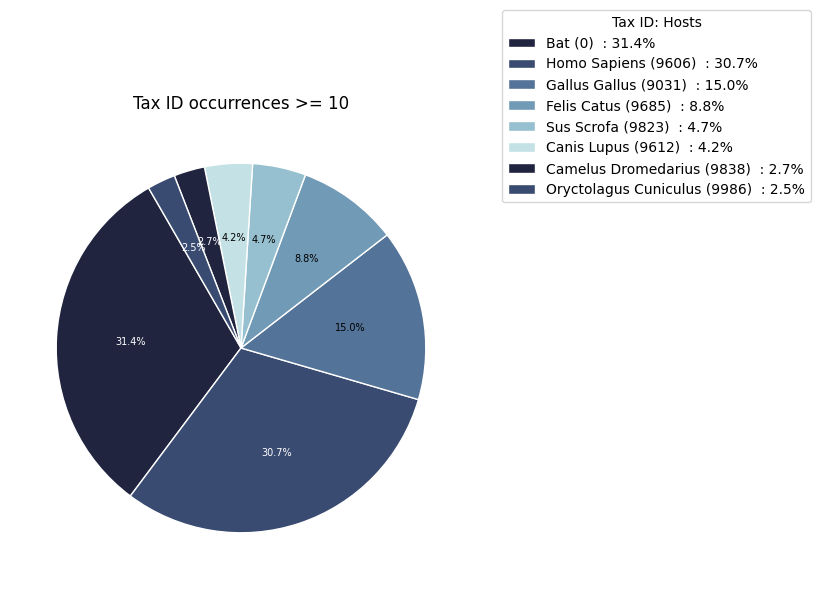

In [204]:
total = top_ids["count"].sum()
legend_labels = [f"{row['host_name']} ({row['virus_host_tax_id']})  : {row['count']/total:.1%}" for _, row in top_ids.iterrows()]
fig, ax = plt.subplots(figsize = (10,6))
wedges, texts, autotexts = ax.pie(
    top_ids["count"],
    labels = None,
    autopct = '%1.1f%%',
    startangle = 120,
    colors = sns.cubehelix_palette(rot=-0.2, reverse = True),
    wedgeprops = {"edgecolor": "white"},
    textprops = {'fontsize': 7}
)

for i, autotext in enumerate(autotexts):
    facecolor = wedges[i].get_facecolor()[:3]  # RGB
    brightness = sum(facecolor)  # crude brightness check
    if brightness < 1.2:  # dark background
        autotext.set_color("white")
plt.title("Tax ID occurrences >= 10")
#look at top ten hosts and see what the minimum count is 
#include those above 10 for pre training . 6 is not enough!

ax.legend(wedges, legend_labels,  title="Tax ID: Hosts", bbox_to_anchor=(1.05, 0.8), loc= "lower left")
output_pdf = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/coronaviridae/top8_id_hosts.pdf")
plt.savefig(output_pdf, dpi = 900)
plt.show()

<b> Findings </b>

When looking at hosts where the tax ids occur at least 10 times, rather than looking at prevalence, we arrive at 8 top hosts
- Bats
- Humans
- Chickens
- Cats
- Pigs
- Wolves
- Camels
- European Rabbits

These top 8 hosts will be used for pre training and fine tuning